# Macro Data Store — Data Gathering Demo

This notebook demonstrates the `macro_data` package: fetching FX rates, commodities, market indices, and macro indicators from FRED, Yahoo Finance, World Bank, and Bank of Thailand into local CSVs, then loading them as pandas DataFrames.

Run this notebook from the `notebooks/` folder with the project's environment (`pip install -e ..[dev]` from the project root if you haven't already).

Sections:
1. Inspect the catalog
2. Fetch from the keyless sources (Yahoo Finance, World Bank)
3. Fetch from the keyed sources (FRED, Bank of Thailand) — and see failure isolation if keys are missing
4. Load series into pandas and plot them
5. Incremental updates — run again and see nothing re-fetched

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from macro_data import list_series, update, update_all, load

pd.set_option("display.max_rows", 20)
%matplotlib inline

## 1. Inspect the catalog

`catalog.yaml` declares every series: which source fetches it and the source-specific params (ticker, FRED series id, World Bank indicator, etc). No code changes are needed to add a new series — just a new entry in the YAML file.

In [2]:
catalog_df = pd.DataFrame(
    [{"id": s.id, "source": s.source, "name": s.name, "params": s.params} for s in list_series()]
)
catalog_df

,id,source,name,params
0,usd_thb,yahoo,USD/THB exchange rate,{'ticker': 'THB=X'}
1,eur_usd,yahoo,EUR/USD exchange rate,{'ticker': 'EURUSD=X'}
2,gold_usd,yahoo,Gold futures (USD/oz),{'ticker': 'GC=F'}
3,brent_oil,yahoo,Brent crude futures (USD/bbl),{'ticker': 'BZ=F'}
4,sp500,yahoo,S&P 500 index,{'ticker': '^GSPC'}
5,set_index,yahoo,SET index (Thailand),{'ticker': '^SET.BK'}
6,th_gdp_usd,worldbank,Thailand GDP (current US$),"{'indicator': 'NY.GDP.MKTP.CD', 'country': 'THA'}"
7,th_inflation,worldbank,"Thailand inflation, CPI (annual %)","{'indicator': 'FP.CPI.TOTL.ZG', 'country': 'THA'}"
8,us_cpi,fred,US CPI (all urban consumers),{'series': 'CPIAUCSL'}
9,fed_funds_rate,fred,US federal funds effective rate,{'series': 'FEDFUNDS'}


## 2. Fetch from the keyless sources

`yahoo` (FX, commodities futures, indices) and `worldbank` (country-level indicators) need no API key. `update(source)` fetches every catalog series for that source and returns a status per series — `"updated (N rows)"`, `"up-to-date"`, or `"failed: ..."`. Each run is incremental: only rows newer than what's already on disk are requested.

In [3]:
yahoo_results = update("yahoo")
worldbank_results = update("worldbank")

pd.concat(
    [pd.Series(yahoo_results, name="status"), pd.Series(worldbank_results, name="status")]
).to_frame()

,status
usd_thb,up-to-date
eur_usd,up-to-date
gold_usd,up-to-date
brent_oil,up-to-date
sp500,up-to-date
set_index,up-to-date
th_gdp_usd,up-to-date
th_inflation,up-to-date


## 3. Fetch from the keyed sources

`fred` and `bot` need `FRED_API_KEY` / `BOT_CLIENT_ID` in a `.env` file (see `.env.example` in the project root). If a key is missing, that series reports `"failed: environment variable ... is not set"` instead of raising — one missing key never blocks the other sources. Once you add real keys and re-run this cell, those series will start updating like the rest.

In [4]:
fred_results = update("fred")
bot_results = update("bot")

pd.concat(
    [pd.Series(fred_results, name="status"), pd.Series(bot_results, name="status")]
).to_frame()

series us_cpi failed: environment variable FRED_API_KEY is not set (put it in a .env file, see .env.example)


series fed_funds_rate failed: environment variable FRED_API_KEY is not set (put it in a .env file, see .env.example)


series usd_thb_bot failed: environment variable BOT_CLIENT_ID is not set (put it in a .env file, see .env.example)


,status
us_cpi,failed: environment variable FRED_API_KEY is n...
fed_funds_rate,failed: environment variable FRED_API_KEY is n...
usd_thb_bot,failed: environment variable BOT_CLIENT_ID is ...


## 4. Load series and plot

`load(series_id)` returns a date-indexed DataFrame with a single `value` column, read straight from the CSV in `data/`.

In [5]:
usd_thb = load("usd_thb")
usd_thb.tail()

,value
date,
2026-07-06,33.240002
2026-07-07,33.266998
2026-07-08,33.360001
2026-07-09,33.470001
2026-07-10,33.299999


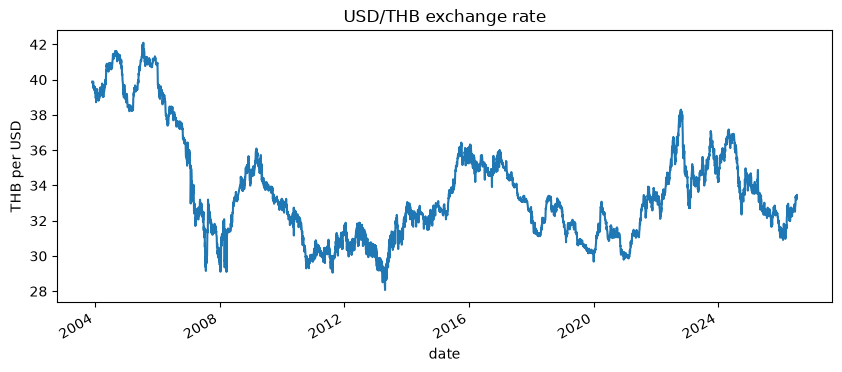

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
usd_thb["value"].plot(ax=ax, title="USD/THB exchange rate")
ax.set_ylabel("THB per USD")
plt.show()

### Comparing multiple series

Each series has its own scale (a rate vs. an index level), so we normalize each to 100 at its first common date before plotting them together.

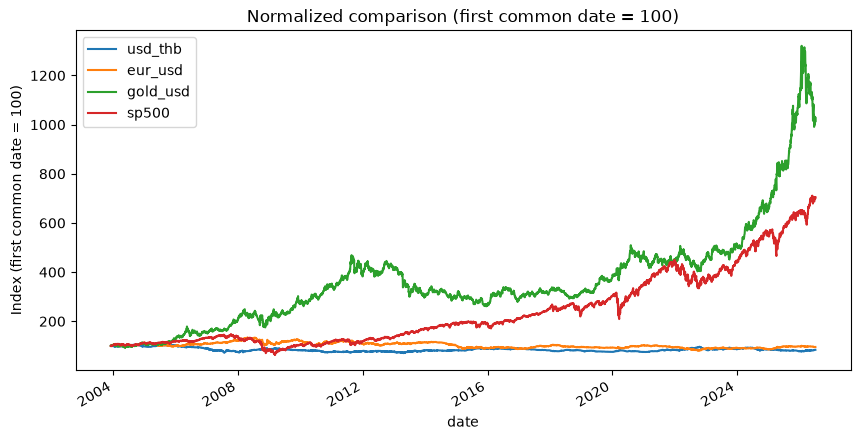

In [7]:
series_ids = ["usd_thb", "eur_usd", "gold_usd", "sp500"]
frames = {sid: load(sid)["value"] for sid in series_ids}
combined = pd.DataFrame(frames).dropna()
normalized = combined / combined.iloc[0] * 100

fig, ax = plt.subplots(figsize=(10, 5))
normalized.plot(ax=ax, title="Normalized comparison (first common date = 100)")
ax.set_ylabel("Index (first common date = 100)")
plt.show()

### Annual indicators

World Bank indicators are yearly, so a bar chart reads better than a line.

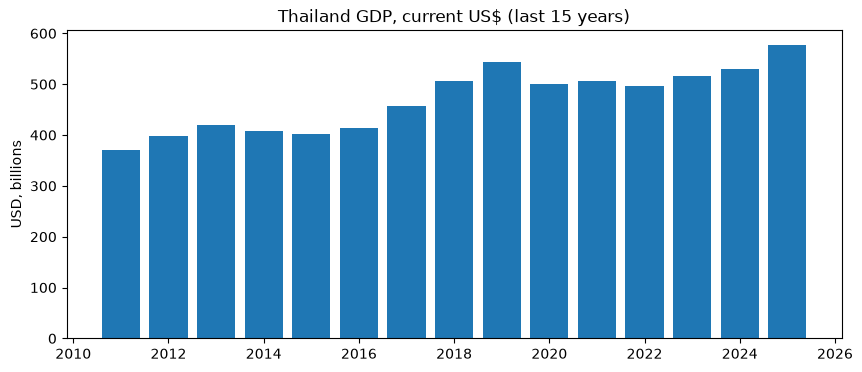

In [8]:
th_gdp = load("th_gdp_usd").tail(15)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(th_gdp.index.year, th_gdp["value"] / 1e9)
ax.set_title("Thailand GDP, current US$ (last 15 years)")
ax.set_ylabel("USD, billions")
plt.show()

## 5. Incremental updates

Running `update_all()` again immediately re-fetches nothing new — every series is already current, so each reports `"up-to-date"` instead of hitting the network for rows it already has.

In [9]:
pd.Series(update_all(), name="status").to_frame()

series us_cpi failed: environment variable FRED_API_KEY is not set (put it in a .env file, see .env.example)


series fed_funds_rate failed: environment variable FRED_API_KEY is not set (put it in a .env file, see .env.example)


series usd_thb_bot failed: environment variable BOT_CLIENT_ID is not set (put it in a .env file, see .env.example)


,status
usd_thb,up-to-date
eur_usd,up-to-date
gold_usd,up-to-date
brent_oil,up-to-date
sp500,up-to-date
set_index,up-to-date
th_gdp_usd,up-to-date
th_inflation,up-to-date
us_cpi,failed: environment variable FRED_API_KEY is n...
fed_funds_rate,failed: environment variable FRED_API_KEY is n...
